# 16-Class Skin Condition Image Classification

This notebook trains a CNN-based image classifier for 16 skin-condition classes.

**Important:** This is an educational/portfolio project, not a medical diagnostic tool. Predictions from images can be wrong and should not be used to diagnose, prescribe treatment, or replace a dermatologist/doctor.

### Classes
Acne, Cellulitis, Dark Spots / Hyperpigmentation, Eczema, Herpes, Impetigo,
Normal Skin, Psoriasis, Rashes, Ringworm, Rosacea, Scabies, Skin Cancer,
Urticaria / Hives, Vitiligo, Wrinkles.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
warnings.filterwarnings("ignore")


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

# --------- CHANGE ONLY THIS PATH ---------
# Kaggle example:
DATASET_DIR = Path("/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system")

# Windows/Jupyter example:
# DATASET_DIR = Path(r"F:\skin_dataset\Skin_Conditions")

# -----------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 16

EPOCHS_HEAD = 12
EPOCHS_FINE = 10

VAL_SIZE = 0.15
TEST_SIZE = 0.15

CLASS_NAMES = [
    "acne",
    "cellulitis",
    "dark spots or Hyperpigmentation",
    "eczema",
    "Herpes",
    "Impetigo",
    "normal",
    "Psoriasis",
    "Rashes",
    "Ringworm",
    "Rosacea",
    "Scabies",
    "skin cancer",
    "urticaria hives",
    "Vitiligo",
    "wrinkle"
]

print("Dataset path:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())


Dataset path: /kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system
Exists: True


## Dataset folder structure

Your dataset should look like this:

```text
Skin_Conditions/
├── Acne/
├── Cellulitis/
├── Dark Spots_Hyperpigmentation/
├── Eczema/
├── Herpes/
├── Impetigo/
├── Normal Skin/
├── Psoriasis/
├── Rashes/
├── Ringworm/
├── Rosacea/
├── Scabies/
├── Skin Cancer/
├── Urticaria_Hives/
├── Vitiligo/
└── Wrinkles/
```

The folder names must match the class names used below. If your actual folder names differ, change `CLASS_NAMES` to match them exactly.


In [3]:
# ============================================================
# 3. FIND THE 16 CLASS FOLDERS AUTOMATICALLY
# ============================================================

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset path does not exist:\n{DATASET_DIR}\n\n"
        "Check the Kaggle Input panel and copy the correct path."
    )


def normalize_name(name):
    """
    Makes folder names easier to compare.
    Example:
    'Dark Spots / Hyperpigmentation'
    -> 'darkspotshyperpigmentation'
    """
    return (
        name.lower()
        .replace(" ", "")
        .replace("_", "")
        .replace("-", "")
        .replace("/", "")
        .replace("\\", "")
    )


# ------------------------------------------------------------
# Search every folder inside the dataset
# ------------------------------------------------------------

candidate_dirs = []

for folder in DATASET_DIR.rglob("*"):
    if folder.is_dir():

        image_files = [
            f for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        ]

        if len(image_files) > 0:
            candidate_dirs.append(folder)


print("Folders containing images:")
print("-" * 70)

for folder in candidate_dirs:
    count = sum(
        1 for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    )
    print(f"{folder} --> {count} images")


# ------------------------------------------------------------
# Match the expected 16 classes
# ------------------------------------------------------------

class_folder_map = {}

normalized_classes = {
    normalize_name(class_name): class_name
    for class_name in CLASS_NAMES
}

for folder in candidate_dirs:

    folder_normalized = normalize_name(folder.name)

    for normalized_expected, expected_class in normalized_classes.items():

        if folder_normalized == normalized_expected:

            class_folder_map[expected_class] = folder
            break


print("\n")
print("=" * 70)
print("MATCHED CLASS FOLDERS")
print("=" * 70)

for class_name in CLASS_NAMES:

    if class_name in class_folder_map:
        folder = class_folder_map[class_name]

        image_count = sum(
            1 for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        )

        print(
            f"{class_name:35s} -> "
            f"{folder} -> {image_count} images"
        )

    else:
        print(
            f"WARNING: {class_name:35s} -> NOT FOUND"
        )


# ------------------------------------------------------------
# Check all 16 classes
# ------------------------------------------------------------

missing_classes = [
    class_name
    for class_name in CLASS_NAMES
    if class_name not in class_folder_map
]

if missing_classes:

    print("\nMissing classes:")
    for class_name in missing_classes:
        print(" -", class_name)

    raise ValueError(
        "\nSome class folders could not be found. "
        "Look at the folder names printed above and update "
        "CLASS_NAMES so they exactly match your dataset."
    )

print("\nAll 16 classes found successfully!")


Folders containing images:
----------------------------------------------------------------------
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/skin_cancer --> 1010 images
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/Rashes --> 1203 images
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/wrinkle --> 1100 images
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/Eczema --> 1192 images
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/cellulitis --> 1155 images
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/acne --> 1185 images
/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/dark_spots or 

In [4]:
# ============================================================
# 3B. CREATE DATAFRAME FROM THE 16 CLASS FOLDERS
# ============================================================

records = []

for class_id, class_name in enumerate(CLASS_NAMES):

    class_dir = class_folder_map[class_name]

    print(f"Loading {class_name} ...")

    image_count = 0

    for file_path in class_dir.rglob("*"):

        if (
            file_path.is_file()
            and file_path.suffix.lower() in VALID_EXTENSIONS
        ):

            records.append({
                "filepath": str(file_path),
                "class_name": class_name,
                "label": class_id
            })

            image_count += 1

    print(f"   {image_count} images loaded")


# Create DataFrame
df = pd.DataFrame(records)

print("\n" + "=" * 70)
print("DATAFRAME CREATED")
print("=" * 70)

print("Total images:", len(df))
print("Columns:", df.columns.tolist())

print("\nImages per class:")

print(
    df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

Loading acne ...
   1185 images loaded
Loading cellulitis ...
   1155 images loaded
Loading dark spots or Hyperpigmentation ...
   1057 images loaded
Loading eczema ...
   1192 images loaded
Loading Herpes ...
   1054 images loaded
Loading Impetigo ...
   1297 images loaded
Loading normal ...
   1240 images loaded
Loading Psoriasis ...
   908 images loaded
Loading Rashes ...
   1203 images loaded
Loading Ringworm ...
   1025 images loaded
Loading Rosacea ...
   1211 images loaded
Loading Scabies ...
   1220 images loaded
Loading skin cancer ...
   1010 images loaded
Loading urticaria hives ...
   1204 images loaded
Loading Vitiligo ...
   795 images loaded
Loading wrinkle ...
   1100 images loaded

DATAFRAME CREATED
Total images: 17856
Columns: ['filepath', 'class_name', 'label']

Images per class:
class_name
acne                               1185
cellulitis                         1155
dark spots or Hyperpigmentation    1057
eczema                             1192
Herpes             

In [5]:

# ============================================================
# CHECK FOR CORRUPTED IMAGES
# ============================================================

from PIL import Image, UnidentifiedImageError

bad_files = []

for file_path in df["filepath"]:
    try:
        with Image.open(file_path) as img:
            img.verify()

    except (UnidentifiedImageError, OSError, ValueError):
        bad_files.append(file_path)

print("Total images:", len(df))
print("Corrupted/unreadable images:", len(bad_files))

if bad_files:
    print("\nCorrupted files:")
    for file_path in bad_files:
        print(file_path)
else:
    print("\n✅ No corrupted images found.")

Total images: 17856
Corrupted/unreadable images: 0

✅ No corrupted images found.


In [6]:
# ============================================================
# 5. ENCODE LABELS
# ============================================================

class_to_id = {name: idx for idx, name in enumerate(CLASS_NAMES)}
id_to_class = {idx: name for name, idx in class_to_id.items()}

df["label"] = df["class_name"].map(class_to_id)

missing_labels = df["label"].isna().sum()
if missing_labels:
    raise ValueError(f"{missing_labels} images have labels that are not in CLASS_NAMES.")

df["label"] = df["label"].astype(int)

print(df.head())
print("\nLabel mapping:")
for idx, name in id_to_class.items():
    print(idx, "->", name)


                                            filepath class_name  label
0  /kaggle/input/datasets/samratshouryajha/ai-pow...       acne      0
1  /kaggle/input/datasets/samratshouryajha/ai-pow...       acne      0
2  /kaggle/input/datasets/samratshouryajha/ai-pow...       acne      0
3  /kaggle/input/datasets/samratshouryajha/ai-pow...       acne      0
4  /kaggle/input/datasets/samratshouryajha/ai-pow...       acne      0

Label mapping:
0 -> acne
1 -> cellulitis
2 -> dark spots or Hyperpigmentation
3 -> eczema
4 -> Herpes
5 -> Impetigo
6 -> normal
7 -> Psoriasis
8 -> Rashes
9 -> Ringworm
10 -> Rosacea
11 -> Scabies
12 -> skin cancer
13 -> urticaria hives
14 -> Vitiligo
15 -> wrinkle


In [7]:
# Check class counts before splitting

print("Total images:", len(df))
print("\nClass counts:")
print(df["class_name"].value_counts().sort_index())

print("\nMinimum class size:")
print(df["label"].value_counts().min())

Total images: 17856

Class counts:
class_name
Herpes                             1054
Impetigo                           1297
Psoriasis                           908
Rashes                             1203
Ringworm                           1025
Rosacea                            1211
Scabies                            1220
Vitiligo                            795
acne                               1185
cellulitis                         1155
dark spots or Hyperpigmentation    1057
eczema                             1192
normal                             1240
skin cancer                        1010
urticaria hives                    1204
wrinkle                            1100
Name: count, dtype: int64

Minimum class size:
795


In [8]:
# ============================================================
# 6. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# First split out the test set.
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

# Then split validation from the remaining training data.
# This gives approximately:
# Train = 70%, Validation = 15%, Test = 15%
relative_val_size = VAL_SIZE / (1.0 - TEST_SIZE)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_size,
    random_state=SEED,
    stratify=train_val_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["class_name"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))


Train: 12498
Validation: 2679
Test: 2679

Train distribution:
class_name
acne                               829
cellulitis                         809
dark spots or Hyperpigmentation    740
eczema                             834
Herpes                             738
Impetigo                           908
normal                             868
Psoriasis                          636
Rashes                             842
Ringworm                           717
Rosacea                            847
Scabies                            854
skin cancer                        707
urticaria hives                    842
Vitiligo                           557
wrinkle                            770
Name: count, dtype: int64


In [9]:
# ============================================================
# 7. CREATE TF.DATA INPUT PIPELINES
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(frame, shuffle=False):
    paths = frame["filepath"].values
    labels = frame["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(frame), 5000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print("Datasets created successfully.")


I0000 00:00:1788717612.312796      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788717612.315750      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created successfully.


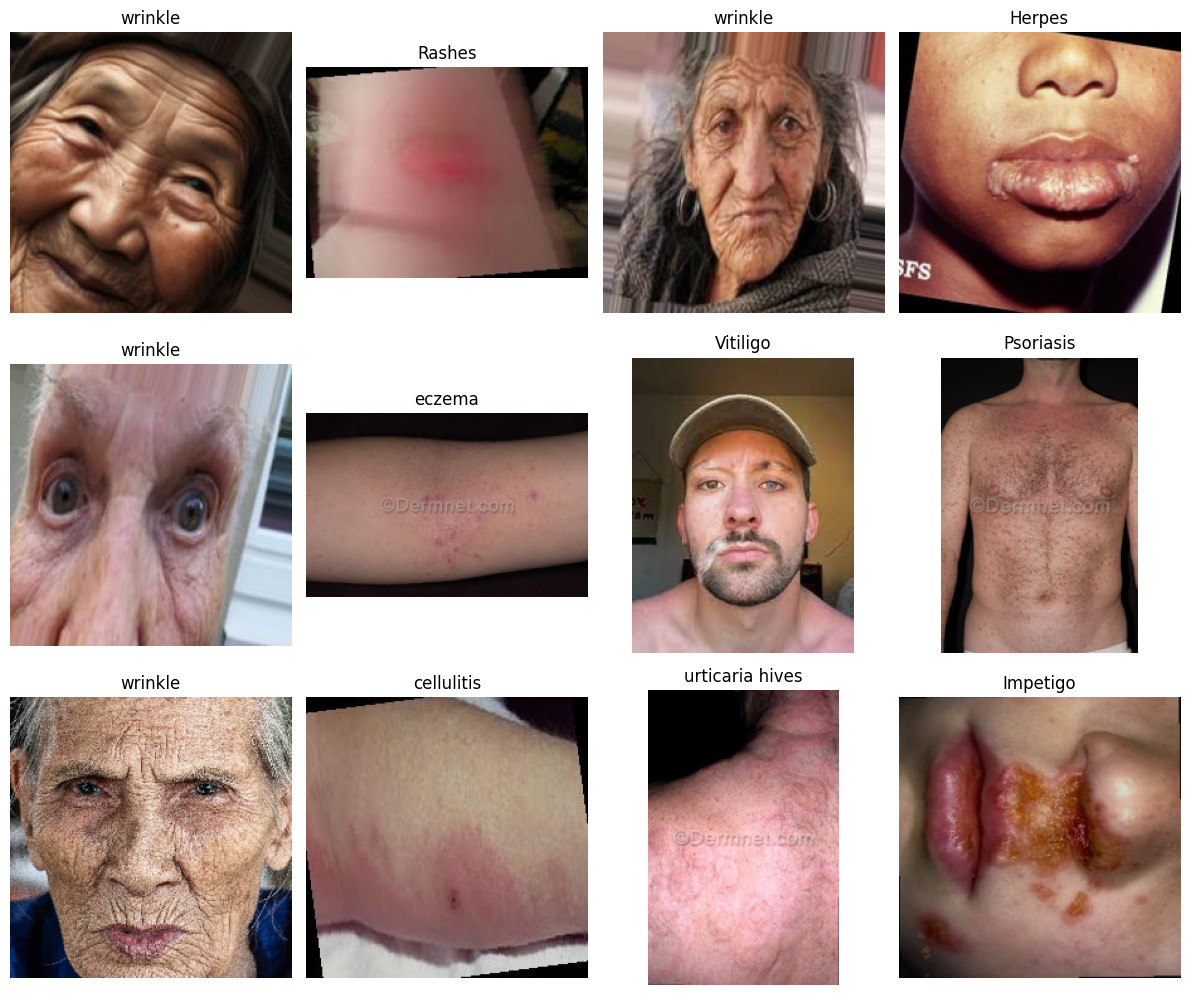

In [10]:
# ============================================================
# 8. VISUALIZE SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12, 10))

sample_df = train_df.sample(min(12, len(train_df)), random_state=SEED)

for i, (_, row) in enumerate(sample_df.iterrows()):
    image = Image.open(row["filepath"]).convert("RGB")
    image.thumbnail((224, 224))

    ax = plt.subplot(3, 4, i + 1)
    ax.imshow(image)
    ax.set_title(row["class_name"])
    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# 9. CLASS WEIGHTS FOR IMBALANCED CLASSES
# ============================================================

classes_present = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=train_df["label"]
)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes_present, weights)
}

print("Class weights:")
for idx in range(NUM_CLASSES):
    print(f"{idx:2d} - {id_to_class[idx]:30s}: {class_weight.get(idx, 0):.4f}")


Class weights:
 0 - acne                          : 0.9422
 1 - cellulitis                    : 0.9655
 2 - dark spots or Hyperpigmentation: 1.0556
 3 - eczema                        : 0.9366
 4 - Herpes                        : 1.0584
 5 - Impetigo                      : 0.8603
 6 - normal                        : 0.8999
 7 - Psoriasis                     : 1.2282
 8 - Rashes                        : 0.9277
 9 - Ringworm                      : 1.0894
10 - Rosacea                       : 0.9222
11 - Scabies                       : 0.9147
12 - skin cancer                   : 1.1048
13 - urticaria hives               : 0.9277
14 - Vitiligo                      : 1.4024
15 - wrinkle                       : 1.0144


In [12]:
# ============================================================
# 10. DATA AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")

print("Augmentation pipeline created.")


Augmentation pipeline created.


In [13]:
# ============================================================
# 11. BUILD CNN MODEL USING MOBILENETV2 TRANSFER LEARNING
# ============================================================

# MobileNetV2 is a CNN architecture.
# We use ImageNet weights for transfer learning.

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,), name="image")

x = data_augmentation(inputs)

# MobileNetV2 expects its standard preprocessing.
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="skin_condition_cnn")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "skin_condition_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,152 (9.90 MB)

 Trainable params: 334,608 (1.28 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [14]:
# ============================================================
# 12. TRAIN CLASSIFICATION HEAD
# ============================================================

checkpoint_path = "best_skin_condition_model.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3877 - loss: 2.2456
Epoch 1: val_accuracy improved from None to 0.64688, saving model to best_skin_condition_model.keras

Epoch 1: finished saving model to best_skin_condition_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 73ms/step - accuracy: 0.4794 - loss: 1.8273 - val_accuracy: 0.6469 - val_loss: 1.1226 - learning_rate: 0.0010
Epoch 2/12
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5802 - loss: 1.3519
Epoch 2: val_accuracy improved from 0.64688 to 0.67040, saving model to best_skin_condition_model.keras

Epoch 2: finished saving model to best_skin_condition_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.5943 - loss: 1.2974 - val_accuracy: 0.6704 - val_loss: 1.0231 - learning_rate: 0.0010
Epoch 3/12
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6179 - loss: 1.1638
Epoch 3: val_accuracy improved from 0.67040 to 0.69280, saving model to best_skin_condition_model.keras

Epoch 3: 

In [15]:
# ============================================================
# 13. FINE-TUNE LAST PART OF THE CNN
# ============================================================

# Unfreeze only the later layers of the pretrained CNN.
base_model.trainable = True

# Keep early layers frozen because they learn generic visual features.
fine_tune_from = max(0, len(base_model.layers) - 40)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Keep BatchNorm layers frozen for more stable fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7369 - loss: 0.7741
Epoch 1: val_accuracy improved from 0.74244 to 0.75028, saving model to best_skin_condition_model.keras

Epoch 1: finished saving model to best_skin_condition_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.7375 - loss: 0.7701 - val_accuracy: 0.7503 - val_loss: 0.7521 - learning_rate: 1.0000e-05
Epoch 2/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7401 - loss: 0.7639
Epoch 2: val_accuracy improved from 0.75028 to 0.75700, saving model to best_skin_condition_model.keras

Epoch 2: finished saving model to best_skin_condition_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.7504 - loss: 0.7283 - val_accuracy: 0.7570 - val_loss: 0.7374 - learning_rate: 1.0000e-05
Epoch 3/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7564 - loss: 0.7139
Epoch 3: val_accuracy did not improve from 0.75700
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accurac

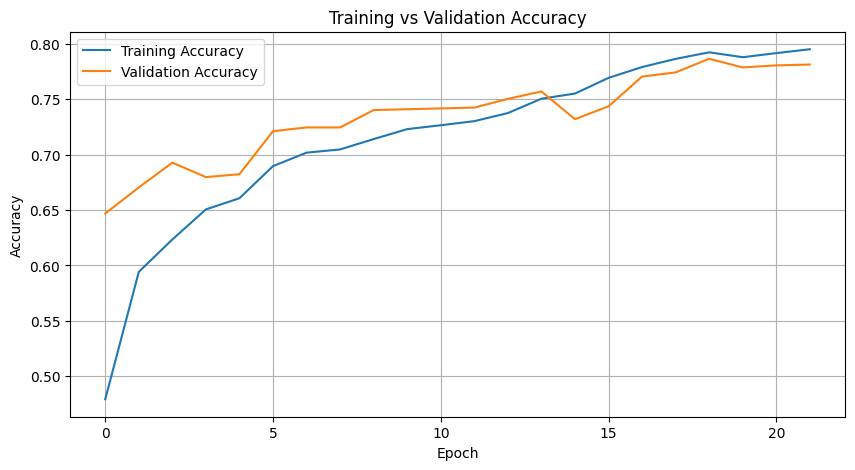

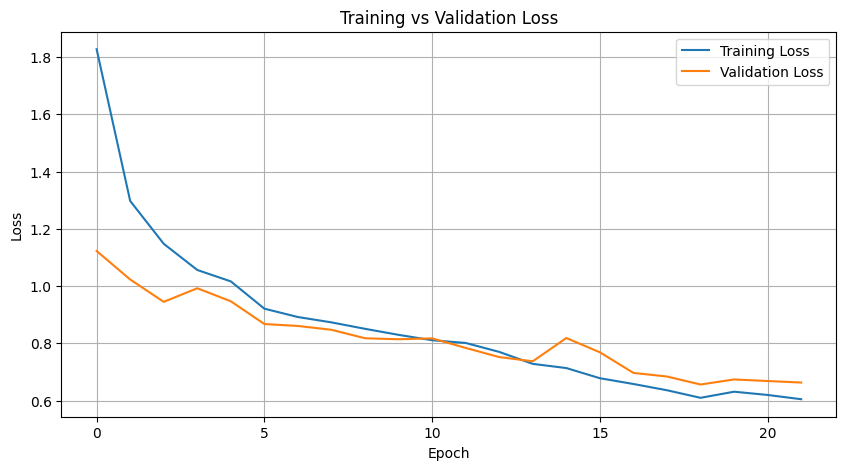

In [16]:
# ============================================================
# 14. PLOT TRAINING AND VALIDATION CURVES
# ============================================================

def combine_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history.get(key, [])
    return history

combined_history = combine_histories(history_head, history_fine)

plt.figure(figsize=(10, 5))
plt.plot(combined_history["accuracy"], label="Training Accuracy")
plt.plot(combined_history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(combined_history["loss"], label="Training Loss")
plt.plot(combined_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
# ============================================================
# 15. LOAD BEST MODEL AND EVALUATE ON TEST SET
# ============================================================

if Path(checkpoint_path).exists():
    model = keras.models.load_model(checkpoint_path)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")


84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7884 - loss: 0.6597

Final Test Accuracy: 78.84%
Final Test Loss: 0.6597


In [18]:
# ============================================================
# 16. GENERATE TEST SET PREDICTIONS
# ============================================================

y_true = []
y_prob = []

for batch_images, batch_labels in test_ds:
    probabilities = model.predict(batch_images, verbose=0)
    y_prob.extend(probabilities)
    y_true.extend(batch_labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("Accuracy from predictions:", f"{accuracy_score(y_true, y_pred) * 100:.2f}%")


Accuracy from predictions: 78.84%


In [19]:
# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df.round(3))

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0
    )
)


,precision,recall,f1-score,support
acne,0.848,0.781,0.813,178.000
cellulitis,0.925,0.994,0.958,173.000
dark spots or Hyperpigmentation,0.826,0.836,0.831,159.000
eczema,0.650,0.436,0.522,179.000
Herpes,0.775,0.785,0.780,158.000
Impetigo,0.955,0.985,0.970,195.000
normal,0.813,0.887,0.848,186.000
Psoriasis,0.596,0.640,0.617,136.000
Rashes,0.915,0.722,0.807,180.000
Ringworm,0.487,0.727,0.583,154.000


                                 precision    recall  f1-score   support

                           acne       0.85      0.78      0.81       178
                     cellulitis       0.92      0.99      0.96       173
dark spots or Hyperpigmentation       0.83      0.84      0.83       159
                         eczema       0.65      0.44      0.52       179
                         Herpes       0.78      0.78      0.78       158
                       Impetigo       0.96      0.98      0.97       195
                         normal       0.81      0.89      0.85       186
                      Psoriasis       0.60      0.64      0.62       136
                         Rashes       0.92      0.72      0.81       180
                       Ringworm       0.49      0.73      0.58       154
                        Rosacea       0.83      0.80      0.82       182
                        Scabies       0.78      0.69      0.73       183
                    skin cancer       0.74      0.

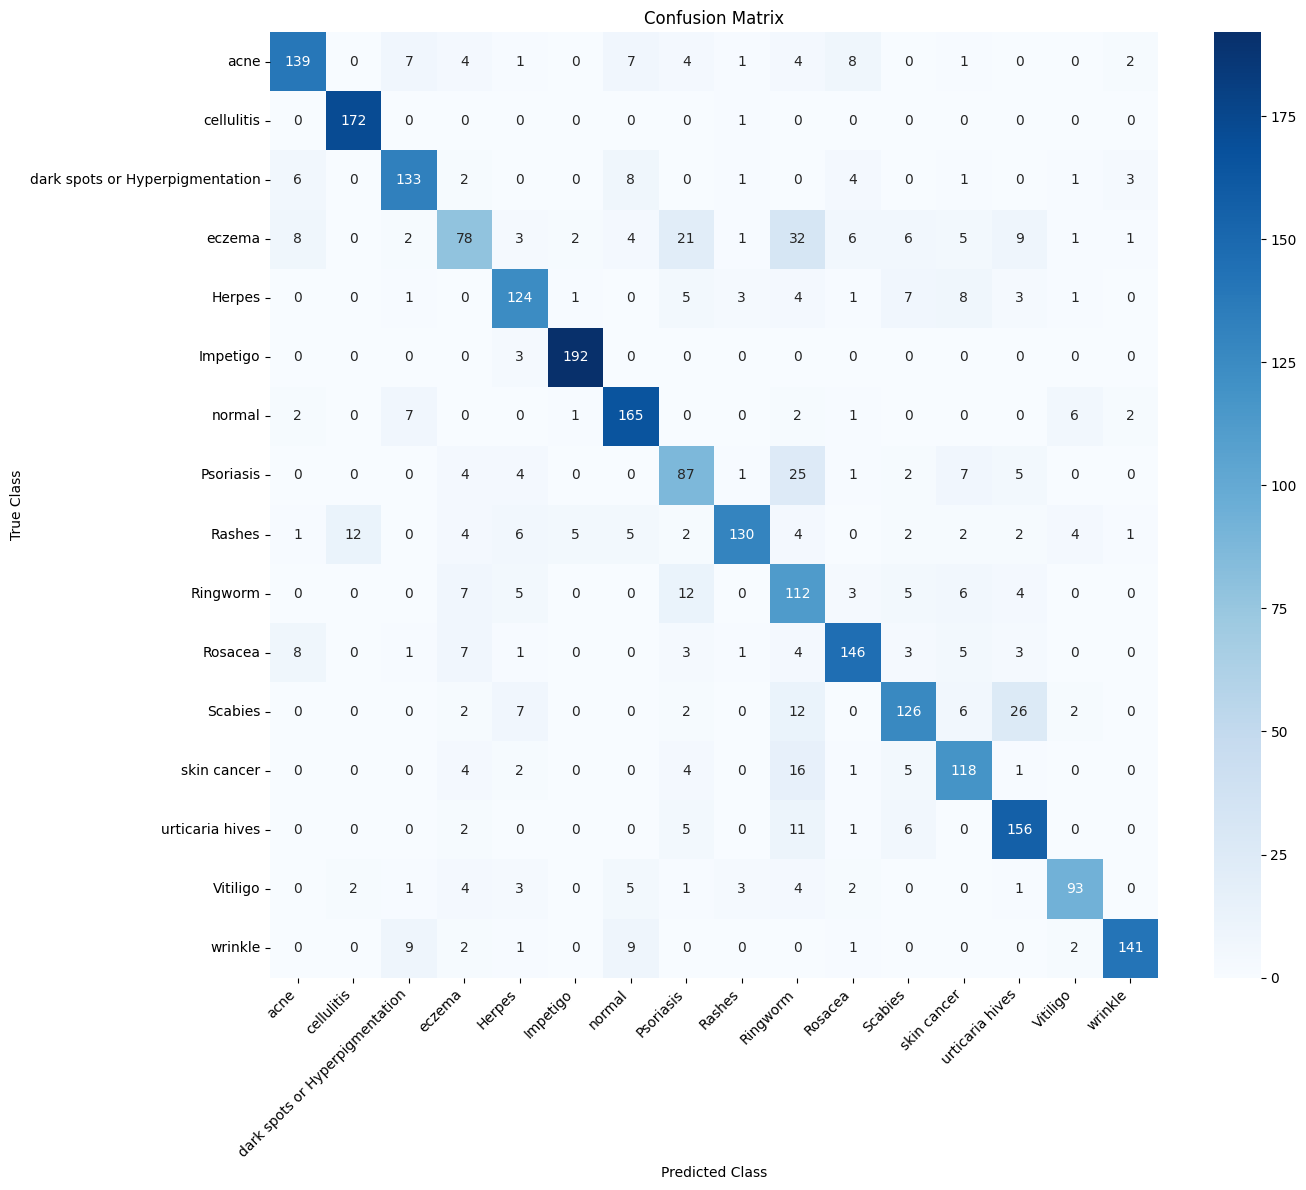

In [20]:
# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# 19. SAVE MODEL AND CLASS MAPPING
# ============================================================

FINAL_MODEL_PATH = "skin_condition_16_class_cnn.keras"
CLASS_MAPPING_PATH = "class_mapping.npy"

model.save(FINAL_MODEL_PATH)
np.save(CLASS_MAPPING_PATH, np.array(CLASS_NAMES, dtype=object))

print("Saved model:", FINAL_MODEL_PATH)
print("Saved class mapping:", CLASS_MAPPING_PATH)


Saved model: skin_condition_16_class_cnn.keras
Saved class mapping: class_mapping.npy


In [22]:
# ============================================================
# 20. RECOMMENDED NEXT STEP / SAFETY MESSAGE
# ============================================================

RECOMMENDATIONS = {
    "Acne": (
        "Recommended next step: use gentle skincare and seek dermatology advice "
        "for persistent or severe acne. Do not self-prescribe medication."
    ),
    "Cellulitis": (
        "Recommended next step: seek prompt medical evaluation. Cellulitis can "
        "require prescription antibiotics and should not be treated from an image prediction."
    ),
    "Dark Spots_Hyperpigmentation": (
        "Recommended next step: use sun protection and have the underlying cause "
        "assessed if pigmentation is persistent or changing."
    ),
    "Eczema": (
        "Recommended next step: use gentle skincare and regular moisturization; "
        "seek professional advice for persistent or severe symptoms."
    ),
    "Herpes": (
        "Recommended next step: seek medical evaluation because image appearance "
        "alone cannot reliably establish herpes or determine treatment."
    ),
    "Impetigo": (
        "Recommended next step: seek medical evaluation because bacterial skin "
        "infections may require prescription treatment."
    ),
    "Normal Skin": (
        "Recommended next step: no abnormality was classified by the model. "
        "Continue routine skincare and sun protection."
    ),
    "Psoriasis": (
        "Recommended next step: seek dermatology advice for persistent scaling, "
        "plaques, or recurrent symptoms."
    ),
    "Rashes": (
        "Recommended next step: have an unexplained or persistent rash assessed by "
        "a healthcare professional, especially if it is spreading, painful, blistering, "
        "or associated with fever."
    ),
    "Ringworm": (
        "Recommended next step: seek appropriate medical evaluation because fungal "
        "skin infections require appropriate antifungal treatment."
    ),
    "Rosacea": (
        "Recommended next step: use gentle skincare and sun protection and consider "
        "dermatology advice for persistent redness or inflammatory lesions."
    ),
    "Scabies": (
        "Recommended next step: seek medical treatment. Scabies requires appropriate "
        "anti-scabies therapy and household/contact measures."
    ),
    "Skin Cancer": (
        "Recommended next step: seek prompt dermatology evaluation for any suspicious, "
        "changing, bleeding, or growing lesion. Do not rely on this classifier for diagnosis."
    ),
    "Urticaria_Hives": (
        "Recommended next step: seek medical advice for persistent or recurrent hives; "
        "urgent care is needed for breathing difficulty or swelling of the lips/tongue."
    ),
    "Vitiligo": (
        "Recommended next step: seek dermatology evaluation if depigmented patches are "
        "new, spreading, or uncertain in cause."
    ),
    "Wrinkles": (
        "Recommended next step: use daily sun protection and a gentle skincare routine; "
        "cosmetic/dermatology options can be discussed with a professional."
    ),
}

def get_recommendation(predicted_class):
    return RECOMMENDATIONS.get(
        predicted_class,
        "Recommended next step: seek professional medical evaluation."
    )


In [23]:
# ============================================================
# 21. CORRECT SINGLE-IMAGE PREDICTION FUNCTION
# ============================================================

def prepare_single_image(image_path):
    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=0)
    return image

def predict_skin_condition(image_path, top_k=3, display_image=True):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    # IMPORTANT:
    # Do not apply training augmentation to prediction.
    # The same image resize + RGB pipeline is used as the model expects.

    image = prepare_single_image(image_path)

    probabilities = model.predict(image, verbose=0)[0]

    top_indices = np.argsort(probabilities)[::-1][:top_k]

    predicted_index = int(top_indices[0])
    predicted_class = id_to_class[predicted_index]
    predicted_confidence = float(probabilities[predicted_index])

    if display_image:
        plt.figure(figsize=(5, 5))
        display_img = Image.open(image_path).convert("RGB")
        plt.imshow(display_img)
        plt.title(
            f"Prediction: {predicted_class}\n"
            f"Model probability: {predicted_confidence * 100:.2f}%"
        )
        plt.axis("off")
        plt.show()

    print("=" * 60)
    print("MODEL PREDICTION")
    print("=" * 60)
    print(f"Predicted class : {predicted_class}")
    print(f"Probability     : {predicted_confidence * 100:.2f}%")
    print("\nTop predictions:")

    for rank, idx in enumerate(top_indices, start=1):
        print(
            f"{rank}. {id_to_class[int(idx)]}: "
            f"{probabilities[int(idx)] * 100:.2f}%"
        )

    print("\nRecommended next step:")
    print(get_recommendation(predicted_class))

    print("\nDISCLAIMER:")
    print(
        "This is an educational AI prediction only. "
        "It is not a medical diagnosis or a prescription."
    )

    return {
        "predicted_class": predicted_class,
        "confidence": predicted_confidence,
        "top_predictions": [
            (id_to_class[int(idx)], float(probabilities[int(idx)]))
            for idx in top_indices
        ]
    }


## 22. Test a New Image

Set `IMAGE_PATH` to any image you want to classify.

**Do not use an image that is already part of the training set when demonstrating generalization.** Use a completely new image where possible.


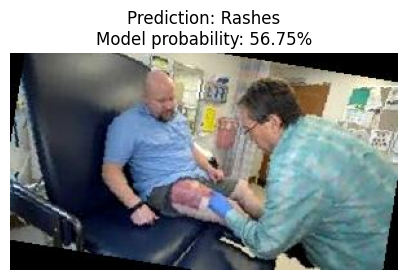

MODEL PREDICTION
Predicted class : Rashes
Probability     : 56.75%

Top predictions:
1. Rashes: 56.75%
2. Vitiligo: 34.19%
3. normal: 6.98%

Recommended next step:
Recommended next step: have an unexplained or persistent rash assessed by a healthcare professional, especially if it is spreading, painful, blistering, or associated with fever.

DISCLAIMER:
This is an educational AI prediction only. It is not a medical diagnosis or a prescription.


In [25]:
# ============================================================
# 22. TEST A NEW IMAGE
# ============================================================

# Example:
# IMAGE_PATH = r"/kaggle/input/your-test-image/test.jpg"
# IMAGE_PATH = r"F:\skin_dataset\test.jpg"

IMAGE_PATH = r"/kaggle/input/datasets/samratshouryajha/ai-powered-skin-condition-detection-system/skin_assesment_dataset/Rashes/aug_0_img1254.jpg"

result = predict_skin_condition(
    IMAGE_PATH,
    top_k=3,
    display_image=True
)


In [26]:
# ============================================================
# 23. OPTIONAL: SAVE PREDICTION RESULT TO CSV
# ============================================================

def prediction_to_dataframe(result):
    rows = []
    for class_name, probability in result["top_predictions"]:
        rows.append({
            "class": class_name,
            "probability": probability
        })
    return pd.DataFrame(rows)

# Example:
# prediction_df = prediction_to_dataframe(result)
# display(prediction_df)
# prediction_df.to_csv("single_image_prediction.csv", index=False)


## 24. Interpretation

When reporting results, use the **test accuracy** and the per-class metrics from the classification report.

Do **not** report training accuracy as the final model accuracy.

Also inspect the confusion matrix. A model with 65% overall accuracy can perform very differently across classes, so precision, recall, and F1-score are important for understanding which conditions the classifier struggles with.


In [27]:
# ============================================================
# 25. QUICK SUMMARY OF FINAL RESULTS
# ============================================================

macro_precision = report_df.loc["macro avg", "precision"]
macro_recall = report_df.loc["macro avg", "recall"]
macro_f1 = report_df.loc["macro avg", "f1-score"]

print("FINAL MODEL SUMMARY")
print("-" * 40)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {macro_precision * 100:.2f}%")
print(f"Macro Recall   : {macro_recall * 100:.2f}%")
print(f"Macro F1-score : {macro_f1 * 100:.2f}%")
print("-" * 40)
print("Classes:", NUM_CLASSES)
print("Test images:", len(test_df))


FINAL MODEL SUMMARY
----------------------------------------
Test Accuracy : 78.84%
Macro Precision: 79.20%
Macro Recall   : 78.52%
Macro F1-score : 78.41%
----------------------------------------
Classes: 16
Test images: 2679
